## **1. Import Libraries**
---

In [ ]:
# # Download ICDAR 2003 dataset
# # https://drive.google.com/file/d/1kUy2tuH-kKBlFCNA0a9sqD2TG4uyvBnV/view
# !gdown 1kUy2tuH-kKBlFCNA0a9sqD2TG4uyvBnV
# !unzip -q icdar2003.zip -d datasets

Downloading...
From (original): https://drive.google.com/uc?id=1kUy2tuH-kKBlFCNA0a9sqD2TG4uyvBnV
From (redirected): https://drive.google.com/uc?id=1kUy2tuH-kKBlFCNA0a9sqD2TG4uyvBnV&confirm=t&uuid=2f3e02c0-3511-433c-bfe6-94278c0a7fa4
To: /kaggle/working/icdar2003.zip
100%|███████████████████████████████████████| 45.7M/45.7M [00:00<00:00, 137MB/s]


In [ ]:
import os
import time
import numpy as np
import xml.etree.ElementTree as ET

import cv2
from PIL import Image
import matplotlib.pyplot as plt

import timm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

import torchvision
from torchvision import transforms

from sklearn.model_selection import train_test_split

## **2. Prepare Data**
---

In [ ]:
def extract_data_from_xml(root_dir):
    xml_path = os.path.join(root_dir, 'words.xml')
    tree     = ET.parse(xml_path)
    root     = tree.getroot()

    img_paths, img_sizes, img_labels, bboxes  = [], [], [], []
    for img in root:
        bbs_of_img    = []
        labels_of_img = []

        for bbs in img.findall('taggedRectangles'):
            for bb in bbs:

                if not bb[0].text.isalnum():
                    continue
                if 'é' in bb[0].text.lower() or 'ñ' in bb[0].text.lower():
                    continue

                bbs_of_img.append(
                    [
                        float(bb.attrib['x']),
                        float(bb.attrib['y']),
                        float(bb.attrib['width']),
                        float(bb.attrib['height']),
                    ]
                )
                labels_of_img.append(bb[0].text.lower())

        img_path = os.path.join(root_dir, img[0].text)
        img_paths.append(img_path)
        img_sizes.append((int(img[1].attrib['x']), int(img[1].attrib['y'])))
        bboxes.append(bbs_of_img)
        img_labels.append(labels_of_img)

    return img_paths, img_sizes, img_labels, bboxes

In [4]:
dataset_dir = 'datasets/SceneTrialTrain'
img_paths, img_sizes, img_labels, bboxes = extract_data_from_xml(dataset_dir)

print(f"Number of images        : {len(img_paths)}")
print(f"Number of bounding boxes: {sum([len(bbs) for bbs in bboxes])}")

Number of images        : 250
Number of bounding boxes: 1097


In [5]:
def split_bounding_boxes(img_paths, img_labels, bboxes, save_dir):
    os.makedirs(save_dir, exist_ok=True)

    count  = 0
    labels = []
    for img_path, img_label, bbs in zip(img_paths, img_labels, bboxes):
        img = Image.open(img_path)

        for label, bb in zip(img_label, bbs):
            cropped_img = img.crop((bb[0], bb[1], bb[0] + bb[2], bb[1] + bb[3]))

            if np.mean(cropped_img) < 35 or np.mean(cropped_img) > 220:
                continue
            if cropped_img.size[0] < 10 or cropped_img.size[1] < 10:
                continue

            filename = f"{count:06d}.jpg"
            cropped_img.save(os.path.join(save_dir, filename))
            new_img_path = os.path.join(save_dir, filename)
            label = new_img_path + '\t' + label
            labels.append(label)

            count += 1

    print(f"Total images: {count}")
    with open(os.path.join(save_dir, 'labels.txt'), 'w') as f:
        for label in labels:
            f.write(f"{label}\n")

In [6]:
save_dir = 'datasets/ocr_dataset'
split_bounding_boxes(img_paths, img_labels, bboxes, save_dir)

img_paths = []
labels    = []
with open(os.path.join(save_dir, 'labels.txt'), 'r') as f:
    for label in f:
        labels.append(label.strip().split('\t')[1])
        img_paths.append(label.strip().split('\t')[0])

Total images: 1088


## **3. Encoder - Decoder**
---

In [7]:
letters = [char.split('.')[0].lower() for char in labels]
letters = "".join(letters)
letters = sorted(list(set(list(letters))))

chars      = "".join(letters)
blank_char = '-'
chars     += blank_char
vocab_size = len(chars)

max_label_len = max([len(label) for label in labels])

print(f"Max label length: {max_label_len}")
print(f"Vocab           : {chars}")
print(f"Vocab size      : {vocab_size}")

Max label length: 14
Vocab           : 0123456789abcdefghijklmnopqrstuvwxyz-
Vocab size      : 37


In [8]:
char_to_idx = {char: idx + 1 for idx, char in enumerate(sorted(chars))}
idx_to_char = {idx: char for char, idx in char_to_idx.items()}

In [9]:
def encode(label, char_to_idx, max_label_len):
    encoded_labels = torch.tensor([char_to_idx[char] for char in label], dtype=torch.long)
    label_len      = len(encoded_labels)
    lengths        = torch.tensor(label_len, dtype=torch.long)
    padded_labels  = F.pad(encoded_labels, (0, max_label_len - label_len), value=0)

    return padded_labels, lengths

In [10]:
def decode(encoded_sequences, idx_to_char, blank_char="-"):
    decoded_sequences = []

    for seq in encoded_sequences:
        decoded_label = []
        prev_char     = None

        for token in seq:
            if token != 0: # Ignore padding (token = 0)
                char = idx_to_char[token.item()]
                
                if char != blank_char: # Append the character if it's not a blank or the same as the previous character
                    if char != prev_char or prev_char == blank_char:
                        decoded_label.append(char)
                prev_char = char

        decoded_sequences.append("".join(decoded_label))
        
    return decoded_sequences

## **4. Data Preprocessing Function**
---

In [11]:
data_transforms = {
    'train': 
        transforms.Compose([
            transforms.Resize((100, 420)),
            transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5,),
            transforms.Grayscale(num_output_channels=1,),
            transforms.GaussianBlur(3),
            transforms.RandomAffine(degrees=1, shear=1,),
            transforms.RandomPerspective(distortion_scale=0.3, p=0.5, interpolation=3,),
            transforms.RandomRotation(degrees=2),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ]),
    'val': 
        transforms.Compose([
            transforms.Resize((100, 420)),
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ]),
}

## **5. Create Dataset**
---

In [12]:
class STRDataset(Dataset):
    def __init__(self, X, y, char_to_idx, max_label_len, label_encoder=None, transform=None,):
        self.transform     = transform
        self.img_paths     = X
        self.labels        = y
        self.char_to_idx   = char_to_idx
        self.max_label_len = max_label_len
        self.label_encoder = label_encoder

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        label    = self.labels[idx]
        img_path = self.img_paths[idx]
        img      = Image.open(img_path).convert('RGB')

        if self.transform:
            img = self.transform(img)

        if self.label_encoder:
            encoded_label, label_len = self.label_encoder(label, self.char_to_idx, self.max_label_len)
            
        return img, encoded_label, label_len

In [13]:
X_train, X_val, y_train, y_val = train_test_split(img_paths, labels, test_size=0.1, random_state=0, shuffle=True,)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.1, random_state=0, shuffle=True,)

train_dataset = STRDataset(X_train, y_train, char_to_idx, max_label_len, encode, transform=data_transforms['train'],)
val_dataset   = STRDataset(X_val, y_val    , char_to_idx, max_label_len, encode, transform=data_transforms['val'],)
test_dataset  = STRDataset(X_test, y_test  , char_to_idx, max_label_len, encode, transform=data_transforms['val'],)

train_loader = DataLoader(train_dataset, batch_size=64 , num_workers=4, pin_memory=True, shuffle=True,)
val_loader   = DataLoader(val_dataset  , batch_size=128, num_workers=4, pin_memory=True, shuffle=False,)
test_loader  = DataLoader(test_dataset , batch_size=128, num_workers=4, pin_memory=True, shuffle=False,)

print(f"Train dataset: {len(train_dataset)}")
print(f"Val dataset  : {len(val_dataset)}")
print(f"Test dataset : {len(test_dataset)}")

Train dataset: 881
Val dataset  : 109
Test dataset : 98


['your', 'students', 'zanusi', 'the', 'up', 'on', 'like', 'council', 'signo', 'university', 'fax', 'customer', 'edition', 'case', 'exit', 'whatever', 'not', 'aspnet', 'dioxide', 'hal', 'world', '6210', 'schol', 'a', '28', 'of', 'know', 'projector', 'spirits', 'toyota', 'extra', 'with', 'mathematics', 'programer', 'alarm', 'the', 'wroxcom', 'traped', '250', 'wrox', 'bot', 'rom', 'and', 'draught', 'monument', 'trafic', 'guines', 'hofman', 'w', 'revolution', 'dental', 'introduction', 'buton', 'digital', 'matsui', 'inteligent', 'into', 'o', 'franklin', 'united', 'under', 'colchester', 'cal', 'liquid']


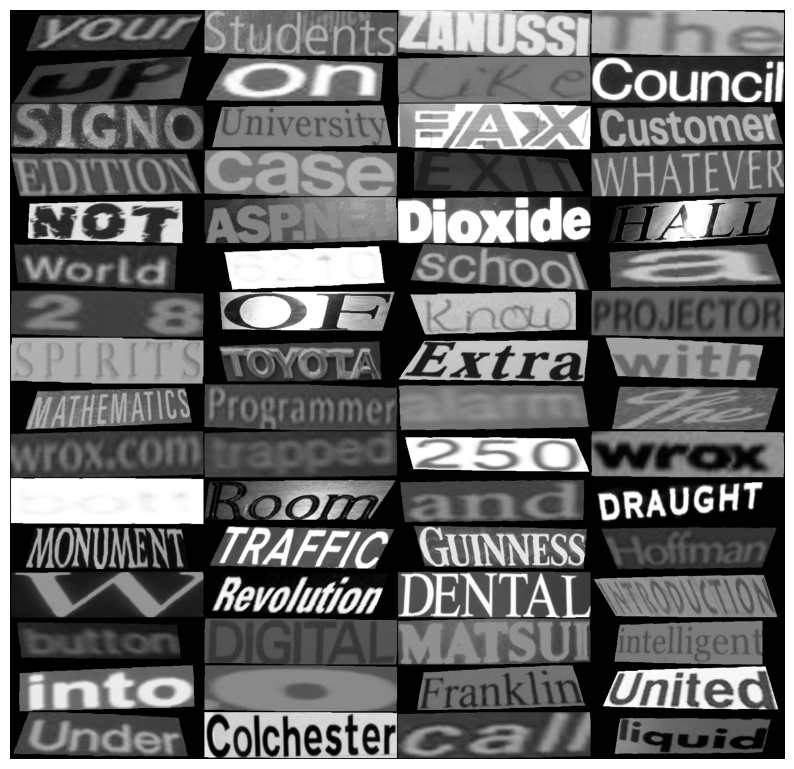

In [14]:
train_features, train_labels, _ = next(iter(train_loader))

# Visualize batch
labels = decode(train_labels, idx_to_char)
print(labels)

grid = torchvision.utils.make_grid(train_features, nrow=4, normalize=True)
plt.figure(figsize=(10, 20))
plt.imshow(np.transpose(grid, (1, 2, 0)))
plt.axis("off")
plt.show()

## **6. Create Model**
---

In [15]:
class CRNN(nn.Module):
    def __init__(self, vocab_size, hidden_size, n_layers, dropout=0.2, unfreeze_layers=3):
        super().__init__()

        backbone = timm.create_model("resnet34", in_chans=1, pretrained=True)
        modules  = list(backbone.children())[:-2]
        modules.append(nn.AdaptiveAvgPool2d((1, None)))
        self.backbone = nn.Sequential(*modules)

        # Unfreeze the last few layers
        for parameter in self.backbone[-unfreeze_layers:].parameters():
            parameter.requires_grad = True

        self.mapSeq = nn.Sequential(
            nn.Linear(512, 512), nn.ReLU(), 
            nn.Dropout(dropout)
        )
        
        self.gru = nn.GRU(
            512, hidden_size, n_layers, 
            bidirectional=True, batch_first=True, 
            dropout=dropout if n_layers > 1 else 0,
        )
        
        self.layer_norm = nn.LayerNorm(hidden_size * 2)
        
        self.out = nn.Sequential(
            nn.Linear(hidden_size * 2, vocab_size), 
            nn.LogSoftmax(dim=2)
        )

    # Disable autocast in case NaN appears when training
    # @torch.autocast(device_type="cuda")
    def forward(self, x):
        x    = self.backbone(x)
        x    = x.permute(0, 3, 1, 2)
        x    = x.view(x.size(0), x.size(1), -1)
        x    = self.mapSeq(x)
        x, _ = self.gru(x)
        x    = self.layer_norm(x)
        x    = self.out(x)
        x    = x.permute(1, 0, 2)  # Based on CTC
        return x

In [16]:
hidden_size     = 256
n_layers        = 3
dropout_prob    = 0.2
unfreeze_layers = 3
device          = "cuda" if torch.cuda.is_available() else "cpu"

model = CRNN(
    vocab_size=vocab_size,
    hidden_size=hidden_size,
    n_layers=n_layers,
    dropout=dropout_prob,
    unfreeze_layers=unfreeze_layers,
).to(device)

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

## **7. Training & Evaluation**
---

In [17]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    
    losses = []
    with torch.no_grad():
        for idx, (inputs, labels, labels_len) in enumerate(dataloader):
            inputs     = inputs.to(device)
            labels     = labels.to(device)
            labels_len = labels_len.to(device)

            outputs     = model(inputs)
            logits_lens = torch.full(size=(outputs.size(1),), fill_value=outputs.size(0), dtype=torch.long).to(device)

            loss = criterion(outputs, labels, logits_lens, labels_len)
            losses.append(loss.item())

    loss = sum(losses) / len(losses)
    return loss

In [ ]:
def fit(model, train_loader, val_loader, criterion, optimizer, scheduler, device, epochs, max_grad_norm=1.0,):
    train_losses = []
    val_losses   = []

    for epoch in range(epochs):
        start              = time.time()
        batch_train_losses = []

        model.train()
        for idx, (inputs, labels, labels_len) in enumerate(train_loader):
            inputs     = inputs.to(device)
            labels     = labels.to(device)
            labels_len = labels_len.to(device)

            optimizer.zero_grad()

            outputs     = model(inputs)
            logits_lens = torch.full(size=(outputs.size(1),), fill_value=outputs.size(0), dtype=torch.long,).to(device)
            
            loss = criterion(outputs, labels.cpu(), logits_lens.cpu(), labels_len.cpu())
            loss.backward()

            # Gradient clipping with a configurable max norm
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
            optimizer.step()

            batch_train_losses.append(loss.item())

        train_loss = sum(batch_train_losses) / len(batch_train_losses)
        train_losses.append(train_loss)

        val_loss = evaluate(model, val_loader, criterion, device)
        val_losses.append(val_loss)
        
        scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']

        print(f"EPOCH {epoch + 1} \t| Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Time: {time.time() - start:.2f}s | LR: {current_lr:.6f}")

    return train_losses, val_losses

In [ ]:
epochs       = 100
lr           = 1e-3
weight_decay = 1e-5

criterion = nn.CTCLoss(blank=char_to_idx[blank_char], zero_infinity=True, reduction="mean",)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay,)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=epochs * 0.5, gamma=0.1)

In [20]:
train_losses, val_losses = fit(
    model, 
    train_loader, val_loader, 
    criterion, optimizer, scheduler, 
    device, epochs, max_grad_norm=1.0
)

EPOCH 1 	| Train Loss: 4.7560 | Val Loss: 3.7040 | Time: 6.88s | LR: 0.001000
EPOCH 2 	| Train Loss: 3.4991 | Val Loss: 3.5078 | Time: 5.27s | LR: 0.001000
EPOCH 3 	| Train Loss: 3.3770 | Val Loss: 3.4358 | Time: 5.37s | LR: 0.001000
EPOCH 4 	| Train Loss: 3.2953 | Val Loss: 3.1973 | Time: 5.26s | LR: 0.001000
EPOCH 5 	| Train Loss: 3.1202 | Val Loss: 2.9961 | Time: 5.29s | LR: 0.001000
EPOCH 6 	| Train Loss: 2.8535 | Val Loss: 2.6709 | Time: 5.33s | LR: 0.001000
EPOCH 7 	| Train Loss: 2.5872 | Val Loss: 2.3499 | Time: 5.31s | LR: 0.001000
EPOCH 8 	| Train Loss: 2.2615 | Val Loss: 2.1219 | Time: 5.36s | LR: 0.001000
EPOCH 9 	| Train Loss: 1.8663 | Val Loss: 1.7310 | Time: 5.41s | LR: 0.001000
EPOCH 10 	| Train Loss: 1.5109 | Val Loss: 1.6729 | Time: 5.47s | LR: 0.001000
EPOCH 11 	| Train Loss: 1.2943 | Val Loss: 1.4855 | Time: 5.46s | LR: 0.001000
EPOCH 12 	| Train Loss: 1.0365 | Val Loss: 1.2527 | Time: 5.45s | LR: 0.001000
EPOCH 13 	| Train Loss: 0.8785 | Val Loss: 1.2424 | Time: 5.4

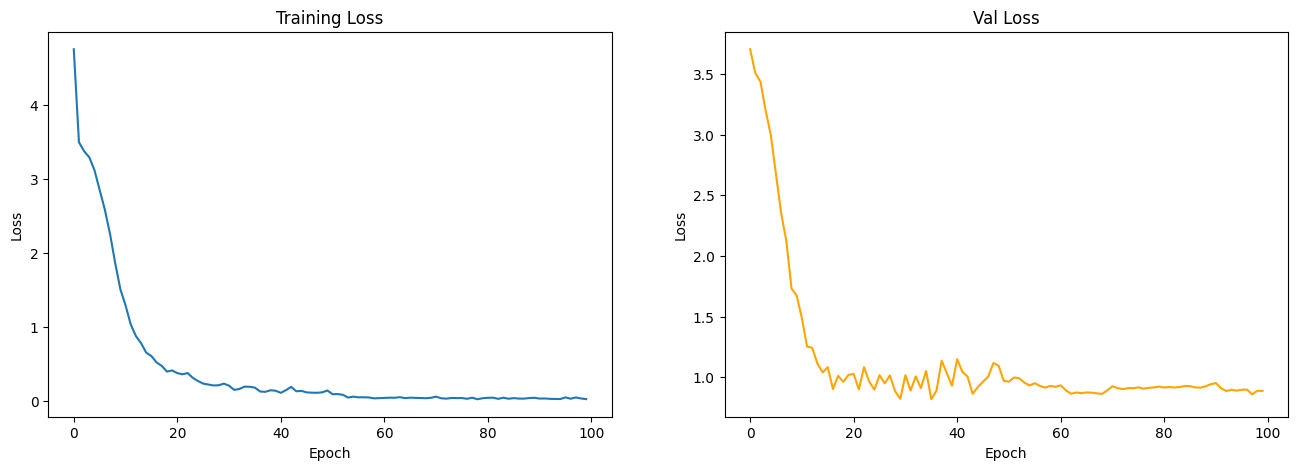

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot(train_losses)
ax[0].set_title("Training Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")

ax[1].plot(val_losses, color="orange")
ax[1].set_title("Val Loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")

plt.show()

In [22]:
val_loss  = evaluate(model, val_loader, criterion, device)
test_loss = evaluate(model, test_loader, criterion, device)

print("Evaluation on val/test dataset")
print(f"Val loss : {val_loss}")
print(f"Test loss: {test_loss}")

Evaluation on val/test dataset
Val loss : 0.8876917958259583
Test loss: 1.401380181312561


In [23]:
save_model_path = "ocr_crnn.pt"
torch.save(model.state_dict(), save_model_path)

## **8. Inference**
---

In [24]:
def predict(model, img):
    model.eval()
    
    with torch.no_grad():
        outputs = model(img)
        print(outputs)
        
def decode_label(encoded_sequences, idx_to_char, blank_char="-"):
    decoded_sequences = []
    
    for seq in encoded_sequences:
        decoded_label = []
        
        for idx, token in enumerate(seq):
            if token != 0:
                char = idx_to_char[token.item()]
                if char != blank_char:
                    decoded_label.append(char)
                
        decoded_sequences.append("".join(decoded_label))
        
    return decoded_sequences

In [ ]:
def inference_on_dataset(model, dataset, idx_to_char, device, num_samples=50, grid_shape=(10, 5)):
    results = []
    for _ in range(num_samples):
        idx = np.random.randint(len(dataset))
        img, label, label_len = dataset[idx]

        img        = img.to(device)
        label      = label.to(device)
        label_text = decode_label([label], idx_to_char)[0]

        # Predict
        logits    = model(img.unsqueeze(0))
        pred_text = decode(logits.permute(1, 0, 2).argmax(2), idx_to_char)[0]

        results.append((img, label_text, pred_text))

    # Visualize prediction
    fig = plt.figure(figsize=(grid_shape[1] * 3.4, grid_shape[0] * 2))
    for i in range(num_samples):
        img, label_text, pred_text = results[i]
        img = img.cpu()
        
        ax    = fig.add_subplot(grid_shape[0], grid_shape[1], i + 1, xticks=[], yticks=[]) 
        title = f"Truth: {label_text} | Pred: {pred_text}"
        ax.imshow(img.permute(1, 2, 0), cmap="gray")
        ax.set_title(title, fontsize=8)
    plt.show()

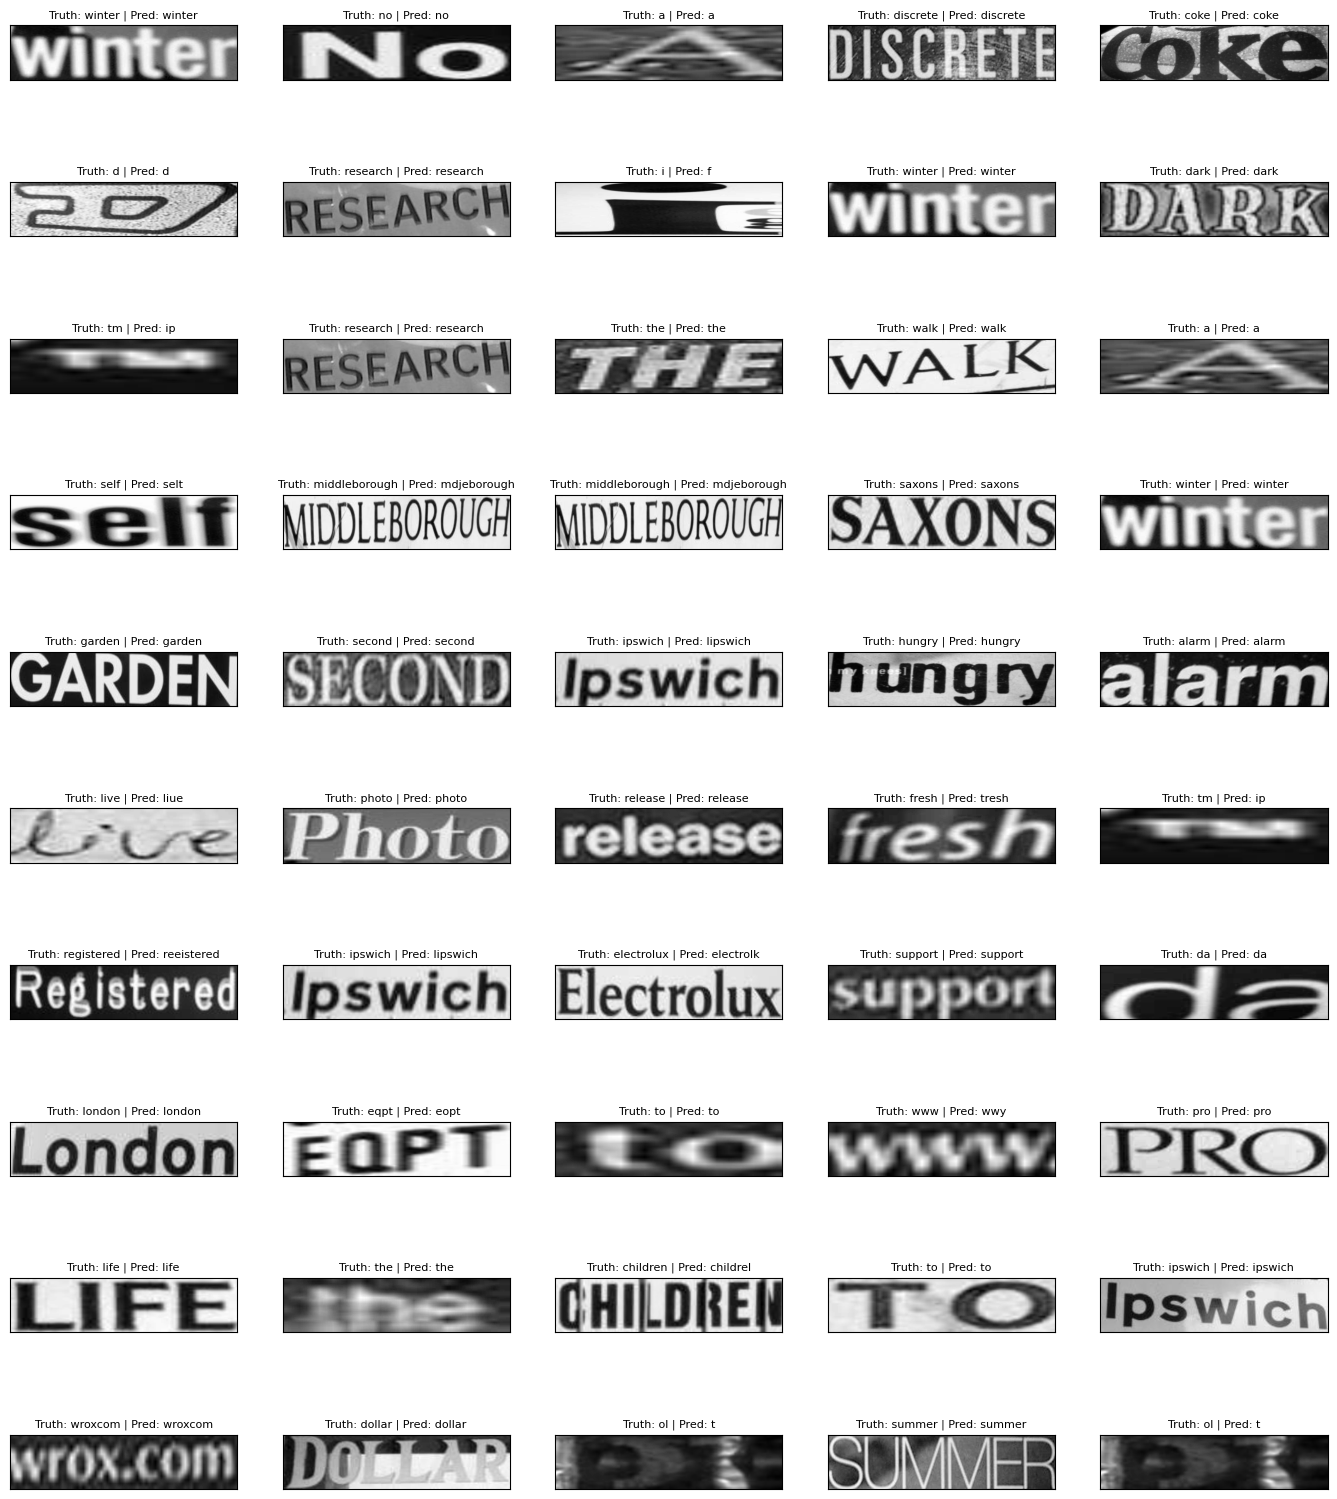

In [26]:
inference_on_dataset(model, test_dataset, idx_to_char, device, num_samples=50)